<a href="https://colab.research.google.com/github/Henry-Gbriel/Curso-USP-An-lise-de-Dados---Esalq/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
pip install factor_analyzer

In [30]:
pip install pingouin

In [31]:
import pandas as pd # Manipular o Data Frame
from factor_analyzer import FactorAnalyzer # Faz PCA / análise fatorial
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity # faz  o teste bartlett
from factor_analyzer.factor_analyzer import calculate_kmo # faz KMO
import pingouin as pg # Faz matriz de correlação com p-values
import seaborn as sns # Plotar gráficos
import numpy as np # Cálculos matematicos
import matplotlib.pyplot as plt # Plotar gráficos

In [32]:
notas = pd.read_excel('/content/Notas Fatorial.xlsx')

print(notas)

      estudante  finanças  custos  marketing  atuária
0      Gabriela       5.8     4.0        1.0      6.0
1   Luiz Felipe       3.1     3.0       10.0      2.0
2      Patrícia       3.1     4.0        4.0      4.0
3       Gustavo      10.0     8.0        8.0      8.0
4       Letícia       3.4     2.0        3.2      3.2
..          ...       ...     ...        ...      ...
95       Sheila       7.7     4.3        5.2      5.1
96        Pedro       9.0     6.0        4.0      9.8
97      Horácio       9.3     6.0        7.0      7.0
98      Leandro       9.0     6.5        3.0      9.0
99       Estela       8.9     5.0        2.0      8.0

[100 rows x 5 columns]


In [33]:
notas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   estudante  100 non-null    object 
 1   finanças   100 non-null    float64
 2   custos     100 non-null    float64
 3   marketing  100 non-null    float64
 4   atuária    100 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.0+ KB


In [34]:
notas.describe()

,finanças,custos,marketing,atuária
count,100.000000,100.000000,100.000000,100.000000
mean,5.834000,4.717000,5.668000,5.314000
std,3.122749,2.455999,2.828351,2.513078
min,0.600000,1.900000,1.000000,1.700000
25%,3.100000,2.900000,3.000000,3.200000
50%,5.800000,4.000000,6.000000,5.000000
75%,9.000000,6.000000,8.000000,7.025000
max,10.000000,10.000000,10.000000,10.000000


In [35]:
#Separar somente as variaveis quantitativas

notas_pca = notas[["finanças", 'custos', "marketing", "atuária"]]

notas_pca.head(30)

,finanças,custos,marketing,atuária
0,5.8,4.0,1.0,6.0
1,3.1,3.0,10.0,2.0
2,3.1,4.0,4.0,4.0
3,10.0,8.0,8.0,8.0
4,3.4,2.0,3.2,3.2
5,10.0,10.0,1.0,10.0
6,5.0,5.0,8.0,5.0
7,5.4,6.0,6.0,6.0
8,5.9,4.0,4.0,4.0
9,6.1,4.0,4.0,4.0


In [36]:
#Aqui fazemos a matriz de correlação
matriz_corr = pg.rcorr(notas_pca, method = 'pearson', upper = 'pval', decimals = 4, pval_stars = {0.01: '***', 0.05: '**', 0.10: '*'})
print(matriz_corr)

'''
  PCA funciona melhor quando as variáveis são correlacionadas.

  Se não houver correlação → PCA não faz sentido.

  Depois o heatmap apenas visualiza isso.

'''

          finanças  custos marketing atuária
finanças         -     ***               ***
custos      0.7556       -               ***
marketing  -0.0295  0.0029         -        
atuária     0.7109  0.8081   -0.0443       -


'\n  PCA funciona melhor quando as variáveis são correlacionadas.\n\n  Se não houver correlação → PCA não faz sentido.\n\n  Depois o heatmap apenas visualiza isso.\n\n'

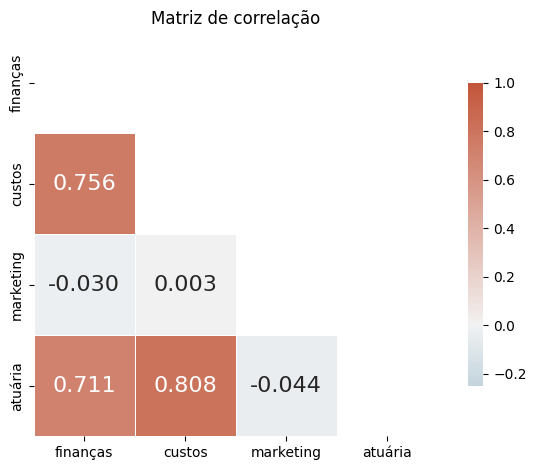

In [37]:
sns.heatmap(notas_pca.corr(),
            mask=mask,
            cmap=cmap,
            vmax=1,
            vmin = -.25,
            center=0,
            square=True,
            linewidths=.5,
            annot = True,
            fmt='.3f',
            annot_kws={'size': 16},
            cbar_kws={"shrink": .75})

plt.title('Matriz de correlação')
plt.tight_layout()
ax.tick_params(axis = 'x', labelsize = 14)
ax.tick_params(axis = 'y', labelsize = 14)
ax.set_ylim(len(corr))

plt.show()

In [38]:
#Teste de Adequação  -----  Teste de Bartlett


bartlett, p_value = calculate_bartlett_sphericity(notas_pca)

print(f'Bartlett statistic: {bartlett}')

print(f'p-value : {p_value}') # Se p < 0.05 → há correlação → PCA é adequado.



Bartlett statistic: 191.87909970380844
p-value : 1.0139139940946973e-38


In [39]:
# Fazemos aqui o cálculo de KMO

'''
 KMO mede adequação da amostra.

    Valores:

    0.8 → excelente

    0.7 → bom

    0.6 → aceitável

    < 0.5 → ruim
'''

kmo_all, kmo_model = calculate_kmo(notas_pca)

print(f'kmo_model : {kmo_model}')


kmo_model : 0.737335331082956


In [40]:
#Definindo a PCA (procedimento preliminar)

#Aqui obtemos os autovalores

fa = FactorAnalyzer()
fa.fit(notas_pca)


ev, v = fa.get_eigenvalues()
print(ev)

[2.51812681 1.0003793  0.29761585 0.18387804]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [41]:
#Critério de Kaiser

# Verificar autovalores com valores maiores que 1
# Existem dois componentes acima de 1

# Parametrizando a PCA para dois fatores (autovalores > 1)

fa.set_params(n_factors = 2, method = 'principal', rotation = None)
fa.fit(notas_pca)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(method='principal', n_factors=2, rotation=None,
               rotation_kwargs={})

In [43]:
#Variância
'''
Retorna:

  Autovalor

  Variância explicada

  Variância acumulada
'''
eigen_fatores = fa.get_factor_variance()
eigen_fatores

tabela_eigen = pd.DataFrame(eigen_fatores)
tabela_eigen.columns = [f"Fator {i+1}" for i, v in enumerate(tabela_eigen.columns)]
tabela_eigen.index = ['Autovalor','Variância', 'Variância Acumulada']
tabela_eigen = tabela_eigen.T

print(tabela_eigen)

         Autovalor  Variância  Variância Acumulada
Fator 1   2.518127   0.629532             0.629532
Fator 2   1.000379   0.250095             0.879627


In [44]:
#Cargas fatoriais

cargas_fatores = fa.loadings_

tabela_cargas = pd.DataFrame(cargas_fatores)
tabela_cargas.columns = [f"Fator {i+1}" for i, v in enumerate(tabela_cargas.columns)]
tabela_cargas.index = notas_pca.columns
tabela_cargas

print(tabela_cargas)

            Fator 1   Fator 2
finanças   0.895398  0.007086
custos     0.934033  0.048581
marketing -0.042466  0.998933
atuária    0.917697 -0.010133


In [45]:
#Determinando as comunalidades

comunalidades = fa.get_communalities()

tabela_comunalidades = pd.DataFrame(comunalidades)
tabela_comunalidades.columns = ['Comunalidades']
tabela_comunalidades.index = notas_pca.columns
tabela_comunalidades

print(tabela_comunalidades)

           Comunalidades
finanças        0.801788
custos          0.874778
marketing       0.999670
atuária         0.842271


In [46]:
#Resultados dos fatores para as observações do dataset (predict)

predict_fatores= pd.DataFrame(fa.transform(notas_pca))
predict_fatores.columns =  [f"Fator {i+1}" for i, v in enumerate(predict_fatores.columns)]

print(predict_fatores)

     Fator 1   Fator 2
0   0.015232 -1.673452
1  -1.082468  1.510196
2  -0.603231 -0.607015
3   1.352586  0.891321
4  -0.984279 -0.926699
..       ...       ...
95  0.121867 -0.169227
96  1.220881 -0.577316
97  0.829146  0.499201
98  1.186171 -0.918969
99  0.807290 -1.299785

[100 rows x 2 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [47]:
# Adicionando ao dataset

notas = pd.concat([notas.reset_index(drop=True), predict_fatores], axis=1)

notas


,estudante,finanças,custos,marketing,atuária,Fator 1,Fator 2
0,Gabriela,5.8,4.0,1.0,6.0,0.015232,-1.673452
1,Luiz Felipe,3.1,3.0,10.0,2.0,-1.082468,1.510196
2,Patrícia,3.1,4.0,4.0,4.0,-0.603231,-0.607015
3,Gustavo,10.0,8.0,8.0,8.0,1.352586,0.891321
4,Letícia,3.4,2.0,3.2,3.2,-0.984279,-0.926699
...,...,...,...,...,...,...,...
95,Sheila,7.7,4.3,5.2,5.1,0.121867,-0.169227
96,Pedro,9.0,6.0,4.0,9.8,1.220881,-0.577316
97,Horácio,9.3,6.0,7.0,7.0,0.829146,0.499201
98,Leandro,9.0,6.5,3.0,9.0,1.186171,-0.918969


In [48]:
#Identificando os scores fatoriais

scores = fa.weights_

tabela_scores = pd.DataFrame(scores)
tabela_scores.columns = [f"Fator {i+1}" for i, v in enumerate(tabela_scores.columns)]
tabela_scores.index = notas_pca.columns
tabela_scores

print(tabela_scores)

            Fator 1   Fator 2
finanças   0.355581  0.007083
custos     0.370924  0.048562
marketing -0.016864  0.998554
atuária    0.364436 -0.010129


        Fator 1 Fator 2
Fator 1       -        
Fator 2     0.0       -
      estudante  finanças  custos  marketing  atuária   Fator 1   Fator 2  \
0      Gabriela       5.8     4.0        1.0      6.0  0.015232 -1.673452   
1   Luiz Felipe       3.1     3.0       10.0      2.0 -1.082468  1.510196   
2      Patrícia       3.1     4.0        4.0      4.0 -0.603231 -0.607015   
3       Gustavo      10.0     8.0        8.0      8.0  1.352586  0.891321   
4       Letícia       3.4     2.0        3.2      3.2 -0.984279 -0.926699   
..          ...       ...     ...        ...      ...       ...       ...   
95       Sheila       7.7     4.3        5.2      5.1  0.121867 -0.169227   
96        Pedro       9.0     6.0        4.0      9.8  1.220881 -0.577316   
97      Horácio       9.3     6.0        7.0      7.0  0.829146  0.499201   
98      Leandro       9.0     6.5        3.0      9.0  1.186171 -0.918969   
99       Estela       8.9     5.0        2.0      8.0  0.807290 -1.299785   

   

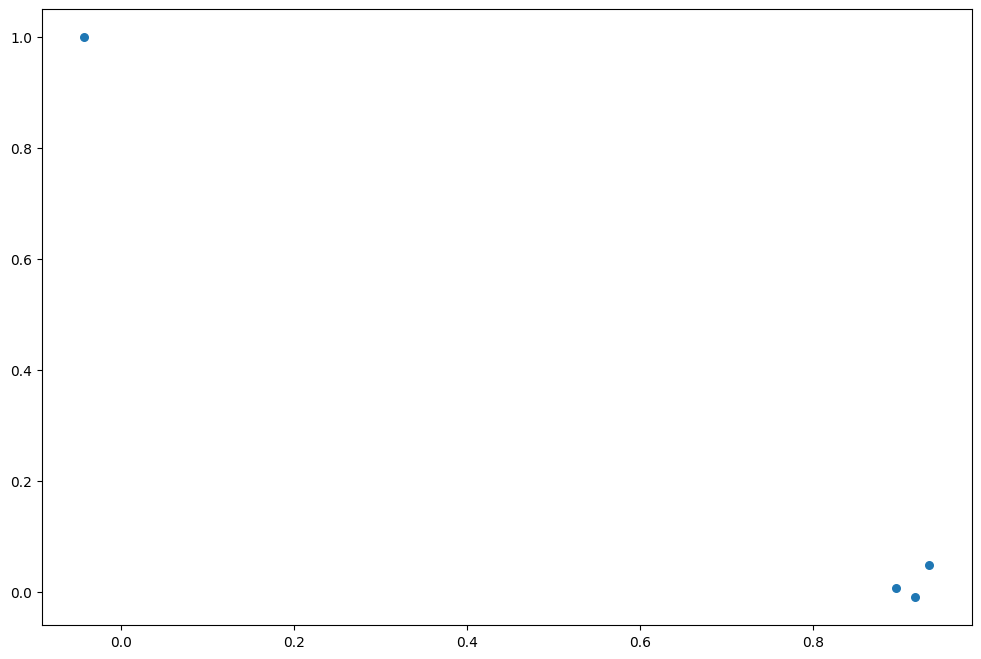

In [49]:
#%% Correlação entre os fatores

# A seguir, verifica-se que a correlação entre os fatores é zero (ortogonais)

corr_fator = pg.rcorr(notas[['Fator 1','Fator 2']], method = 'pearson', upper = 'pval', decimals = 4, pval_stars = {0.01: '***', 0.05: '**', 0.10: '*'})
print(corr_fator)

#%% Criando um ranking

notas['Ranking'] = 0

for index, item in enumerate(list(tabela_eigen.index)):
    variancia = tabela_eigen.loc[item]['Variância']

    notas['Ranking'] = notas['Ranking'] + notas[tabela_eigen.index[index]]*variancia

print(notas)

#%% Gráfico das cargas fatoriais e suas variâncias nos componentes principais

plt.figure(figsize=(12,8))

tabela_cargas_chart = tabela_cargas.reset_index()

plt.scatter(tabela_cargas_chart['Fator 1'], tabela_cargas_chart['Fator 2'], s=30)


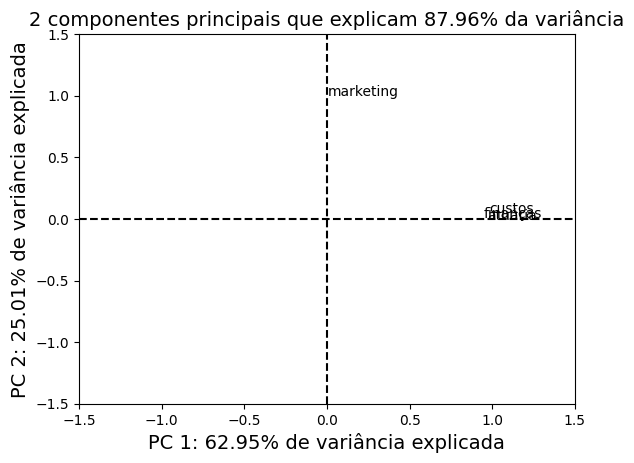

In [50]:
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x'] + 0.05, point['y'], point['val'])

label_point(x = tabela_cargas_chart['Fator 1'],
            y = tabela_cargas_chart['Fator 2'],
            val = tabela_cargas_chart['index'],
            ax = plt.gca())

plt.axhline(y=0, color='black', ls='--')
plt.axvline(x=0, color='black', ls='--')
plt.ylim([-1.5,1.5])
plt.xlim([-1.5,1.5])
plt.title(f"{tabela_eigen.shape[0]} componentes principais que explicam {round(tabela_eigen['Variância'].sum()*100,2)}% da variância", fontsize=14)
plt.xlabel(f"PC 1: {round(tabela_eigen.iloc[0]['Variância']*100,2)}% de variância explicada", fontsize=14)
plt.ylabel(f"PC 2: {round(tabela_eigen.iloc[1]['Variância']*100,2)}% de variância explicada", fontsize=14)
plt.show()

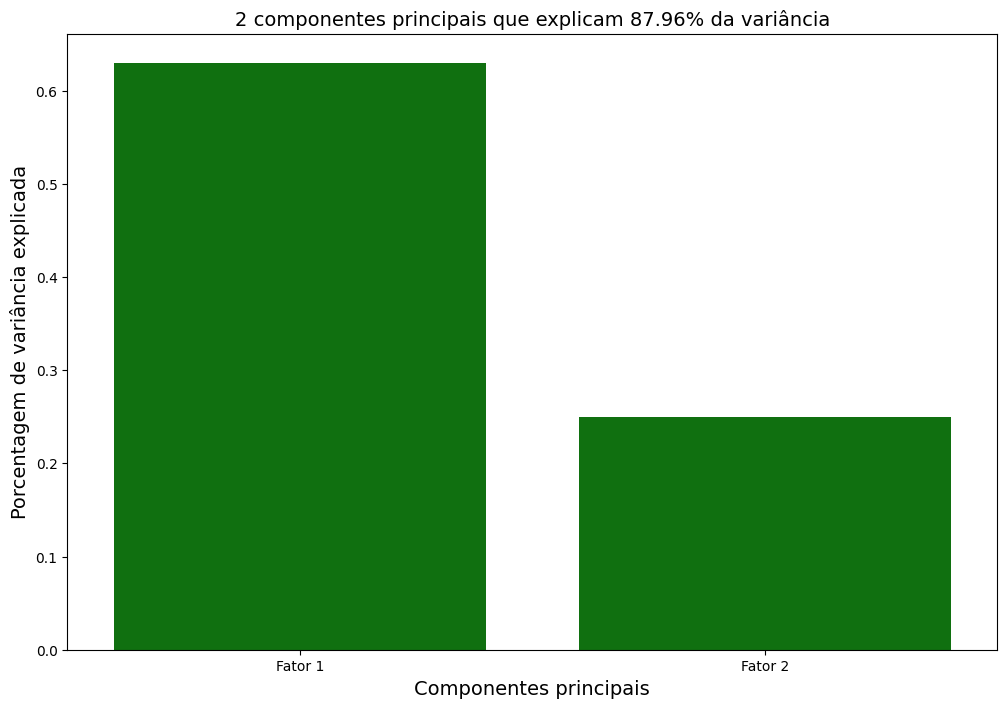

In [51]:
#%% Gráfico da variância acumulada dos componentes principais

plt.figure(figsize=(12,8))

plt.title(f"{tabela_eigen.shape[0]} componentes principais que explicam {round(tabela_eigen['Variância'].sum()*100,2)}% da variância", fontsize=14)
sns.barplot(x=tabela_eigen.index, y=tabela_eigen['Variância'], data=tabela_eigen, color='green')
plt.xlabel("Componentes principais", fontsize=14)
plt.ylabel("Porcentagem de variância explicada", fontsize=14)
plt.show()